In [26]:
!pip install numpy pandas matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.1 MB/s  0:00:00
Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [46]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import math

In [ ]:
def calculate_stability(h, k, c):
    """
    Calculate the stability of the finite difference method.

    h = step size in space

    k = step size in time

    c = diffusion constant
    """
    return c**2 * k / h**2

In [116]:
def heat_fdm(initial, left_bc, right_bc, L=1, T=1, c=1):
    """
    Finite difference solver for the heat equation.

    initial : list
        values of u(x_i,0)

    left_bc : list
        boundary values at x=0 for each time step

    right_bc : list
        boundary values at x=L for each time step
    
    L = length of rod

    T = time to solve for

    c = diffusion constant
    """

    n = len(initial) - 1
    m = len(left_bc) - 1

    h = L / n
    k = T / m

    s = c**2 * k / h**2

    # solution array
    u = np.zeros((m+1, n+1))

    # initial condition
    u[0, :] = initial

    # boundary conditions
    for j in range(m+1):
        u[j, 0] = left_bc[j]
        u[j, -1] = right_bc[j]

    # finite difference iteration
    for j in range(m):
        for i in range(1, n):
            u[j+1, i] = u[j, i] + s * (u[j, i+1] - 2*u[j, i] + u[j, i-1])
            
    x = np.linspace(0, L, n+1)
    t = np.linspace(0, T, m+1)
    grid = pd.DataFrame(u, columns=[f"x{i:.2f}" for i in x])
    grid = grid.round(1)
    grid.insert(0, "t", t)


    return grid, calculate_stability(h, k, c)

In [131]:
def heatmap(grid): 
    t = grid["t"].values
    x = np.array([float(col[1:]) for col in grid.columns if col != "t"])
    heat = grid.drop(columns="t").values

    plt.imshow(
        heat,
        aspect='auto',
        origin='lower',
        extent=[x.min(), x.max(), t.min(), t.max()],
        cmap='coolwarm'
    )

    plt.xlabel("Space (x)")
    plt.ylabel("Time (t)")
    plt.title("Heat Distribution Over Time")

    plt.colorbar(label="Temperature")
    plt.show()

Dirichlet Boundary Conditions: random initial temperatures

Inital Condition: [80, 74, 97, 51, -41]
Solution:
          t  x0.00  x0.25  x0.50  x0.75  x1.00
0  0.000000    0.0   74.0   97.0   51.0    0.0
1  0.166667    0.0   65.5   85.5   50.2    0.0
2  0.333333    0.0   57.9   76.3   47.7    0.0
3  0.500000    0.0   51.3   68.5   44.5    0.0
4  0.666667    0.0   45.6   61.6   41.1    0.0
5  0.833333    0.0   40.7   55.5   37.7    0.0
6  1.000000    0.0   36.4   50.1   34.4    0.0
Stability: 0.16666666666666666
The method is stable.


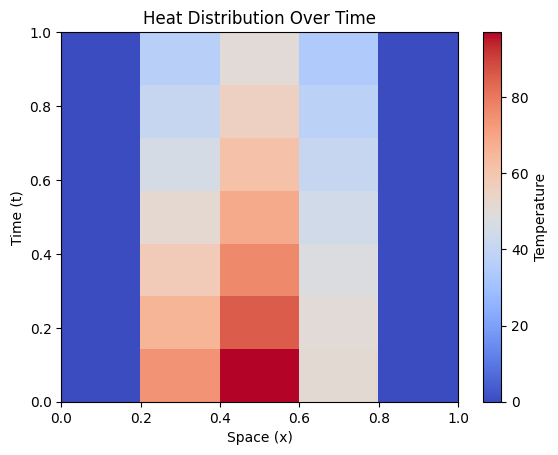

In [133]:
initial = [random.randint(-50, 100) for _ in range(5)]
left_bc = [0, 0, 0, 0, 0, 0, 0]
right_bc = [0, 0, 0, 0, 0, 0, 0]

print("Inital Condition:", initial)
grid, stability = heat_fdm(initial, left_bc, right_bc, c = 1/4)

print("Solution:")
print(grid)

if stability > 0.5:
    print("Stability:", stability)
    print("The method is unstable.")
else:
    print("Stability:", stability)
    print("The method is stable.")

heatmap(grid)


Random Boundary Conditions

In [101]:
import random

initial = [random.randint(-100, 100) for _ in range(5)]
left_bc = [random.randint(-100, 100) for _ in range(5)]
right_bc = [random.randint(-100, 100) for _ in range(5)]

print("Inital Condition:", initial)
grid, stability = heat_fdm(initial, left_bc, right_bc)

print("Right Boundary Conditions:", right_bc)
print("Left Boundary Conditions:", left_bc)

print("Solution:")
print(grid)

if stability > 0.5:
    print("Stability:", stability)
    print("The method is unstable.")
else:
    print("Stability:", stability)
    print("The method is stable.")


Inital Condition: [-58, 39, 65, 69, -46]
Right Boundary Conditions: [-26, 13, 62, 72, -19]
Left Boundary Conditions: [99, -75, 91, -97, -81]
Solution:
      t  x0.00     x0.25    x0.50    x0.75  x1.00
0  0.00   99.0      39.0     65.0     69.0  -26.0
1  0.25  -75.0     383.0    -23.0   -327.0   13.0
2  0.50   91.0   -3073.0    385.0   2249.0   62.0
3  0.75  -97.0   23415.0  -5991.0 -13955.0   72.0
4  1.00  -81.0 -188257.0  79777.0  74009.0  -19.0
Stability: 4.0
The method is unstable.


In [19]:
import math

def sample_function(f, L, num_points):
    """Sample the function f at equal intervals over [0, L] (inclusive)."""
    if num_points < 2:
        raise ValueError("num_points must be 2 or more")
    step = L / (num_points - 1)
    samples = [f(step * i) for i in range(num_points)]
    return samples


## Analytic Solution of the Heat Equation

We solve the 1-D heat equation

$$
u_t = c^2 u_{xx}, \qquad 0<x<\pi,\; t>0
$$

with boundary conditions

$$
u(0,t)=0, \qquad u(\pi,t)=0
$$

and initial condition

$$
u(x,0)=\sin(x)
$$

---

### Separation of Variables

Assume a solution of the form

$$
u(x,t)=X(x)T(t)
$$

Substituting into the PDE gives

$$
XT' = c^2 X''T
$$

Dividing by \(XT\):

$$
\frac{T'}{c^2T} = \frac{X''}{X} = -\lambda
$$

---

### Spatial Eigenvalue Problem

$$
X''+\lambda X=0
$$

with boundary conditions

$$
X(0)=0,\qquad X(\pi)=0
$$

The eigenvalues and eigenfunctions are

$$
\lambda_n=n^2
$$

$$
X_n(x)=\sin(nx)
$$

---

### Time Solution

$$
T_n(t)=e^{-c^2 n^2 t}
$$

For \(c=1\),

$$
T_n(t)=e^{-n^2 t}
$$

---

### General Solution

$$
u(x,t)=\sum_{n=1}^{\infty} b_n \sin(nx)e^{-n^2 t}
$$

---

### Applying the Initial Condition

The initial condition is

$$
u(x,0)=\sin(x)
$$

Since this is already one of the eigenfunctions, the Fourier series contains only one term:

$$
b_1=1, \qquad b_n=0 \; \text{for } n>1
$$

---

### Final Analytic Solution

Therefore the exact solution is

$$
u(x,t)=\sin(x)e^{-t}
$$

In [43]:
def analytic_solution(x, t):
    return math.sin(x) * math.exp(-t)